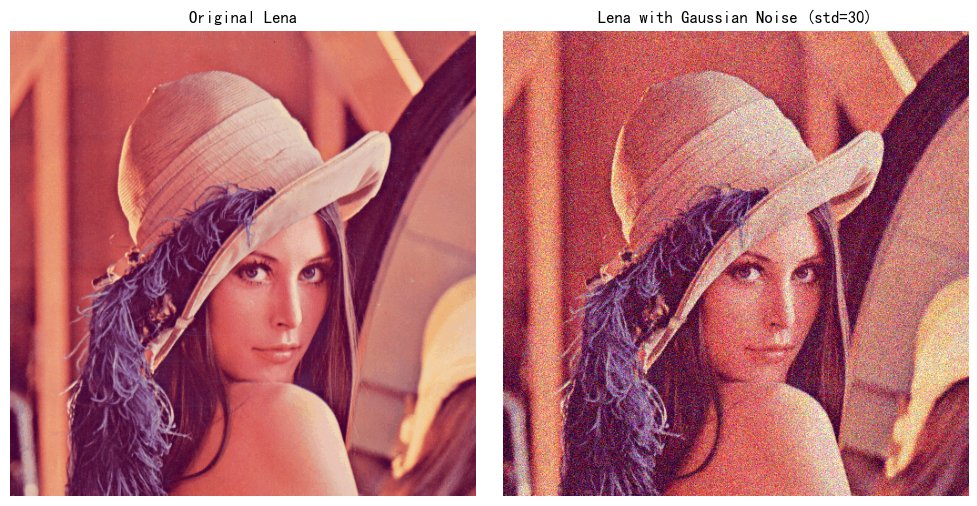

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0, std=20):
    """
    给图像添加高斯噪声
    :param image: 输入图像（BGR格式，OpenCV读取）
    :param mean: 高斯噪声的均值（通常设为0）
    :param std: 高斯噪声的标准差（值越大，噪声越明显）
    :return: 添加噪声后的图像
    """
    # 将图像转换为浮点型，避免数值溢出/截断
    img_float = image.astype(np.float32)

    # 生成与图像形状相同的高斯噪声矩阵
    # np.random.normal: 生成符合正态分布的随机数
    noise = np.random.normal(mean, std, image.shape)

    # 将噪声添加到图像上
    noisy_img = img_float + noise

    # 将像素值裁剪到 [0, 255] 范围（图像像素的合法范围），并转回uint8类型
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    return noisy_img

# 主程序
if __name__ == "__main__":
    # 1. 读取Lena图像（如果本地没有lena.jpg，需先下载或替换路径）
    # 若没有本地文件，也可以用OpenCV示例图像（需确保OpenCV版本支持）
    # 备选方案：lena = cv2.imread(cv2.samples.findFile("lena.jpg"))
    lena = cv2.imread("lenna.jpg")

    # 检查图像是否读取成功
    if lena is None:
        print("错误：未找到lena.jpg，请确认文件路径正确！")
    else:
        # 2. 转换为RGB格式（OpenCV默认BGR，matplotlib显示需要RGB）
        lena_rgb = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)

        # 3. 添加高斯噪声（可调整std值改变噪声强度）
        lena_noisy = add_gaussian_noise(lena, mean=0, std=30)
        lena_noisy_rgb = cv2.cvtColor(lena_noisy, cv2.COLOR_BGR2RGB)

        # 4. 显示原图和加噪后的图像
        plt.figure(figsize=(10, 5))

        # 显示原图
        plt.subplot(1, 2, 1)
        plt.imshow(lena_rgb)
        plt.title("Original Lena")
        plt.axis("off")

        # 显示加噪后的图像
        plt.subplot(1, 2, 2)
        plt.imshow(lena_noisy_rgb)
        plt.title("Lena with Gaussian Noise (std=30)")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        # 可选：保存加噪后的图像
        cv2.imwrite("lenna_noisy.jpg", lena_noisy)


building.jpg


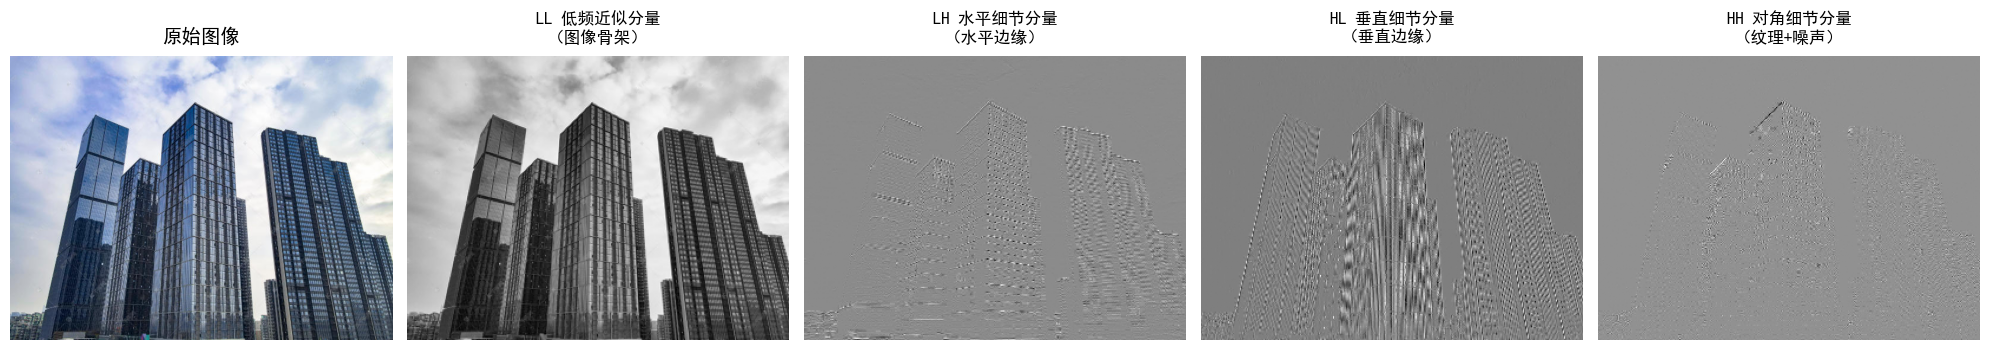

原始图像尺寸：(480, 646) (高×宽)
各频带尺寸：(241, 324) (均为原图1/4)
使用小波基：db2

lighthouse.jpg


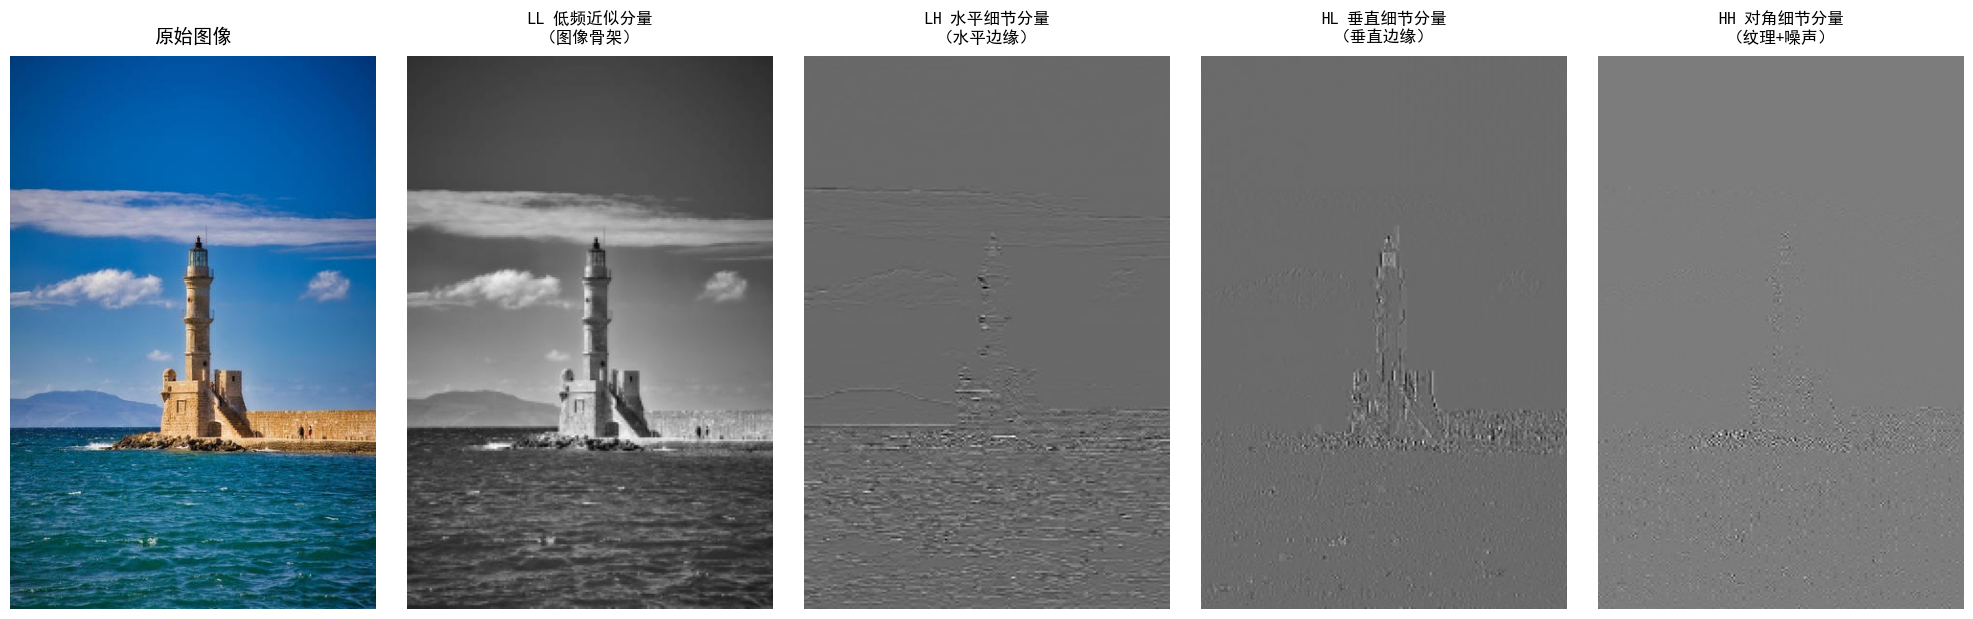

原始图像尺寸：(577, 382) (高×宽)
各频带尺寸：(290, 192) (均为原图1/4)
使用小波基：db2

cat.jpg


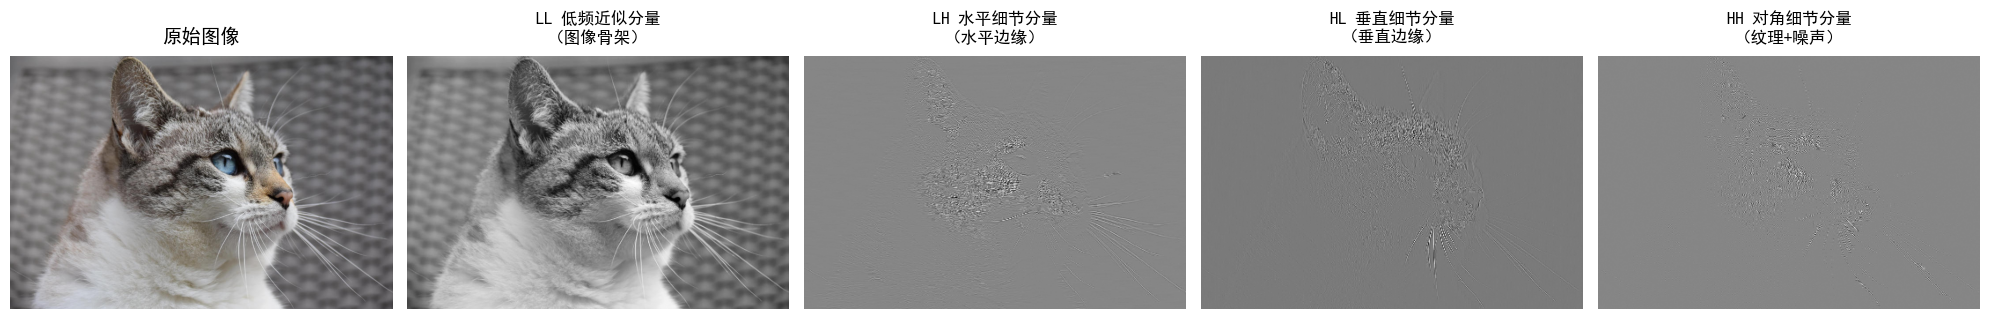

原始图像尺寸：(574, 866) (高×宽)
各频带尺寸：(288, 434) (均为原图1/4)
使用小波基：db2

lenna_noisy.jpg


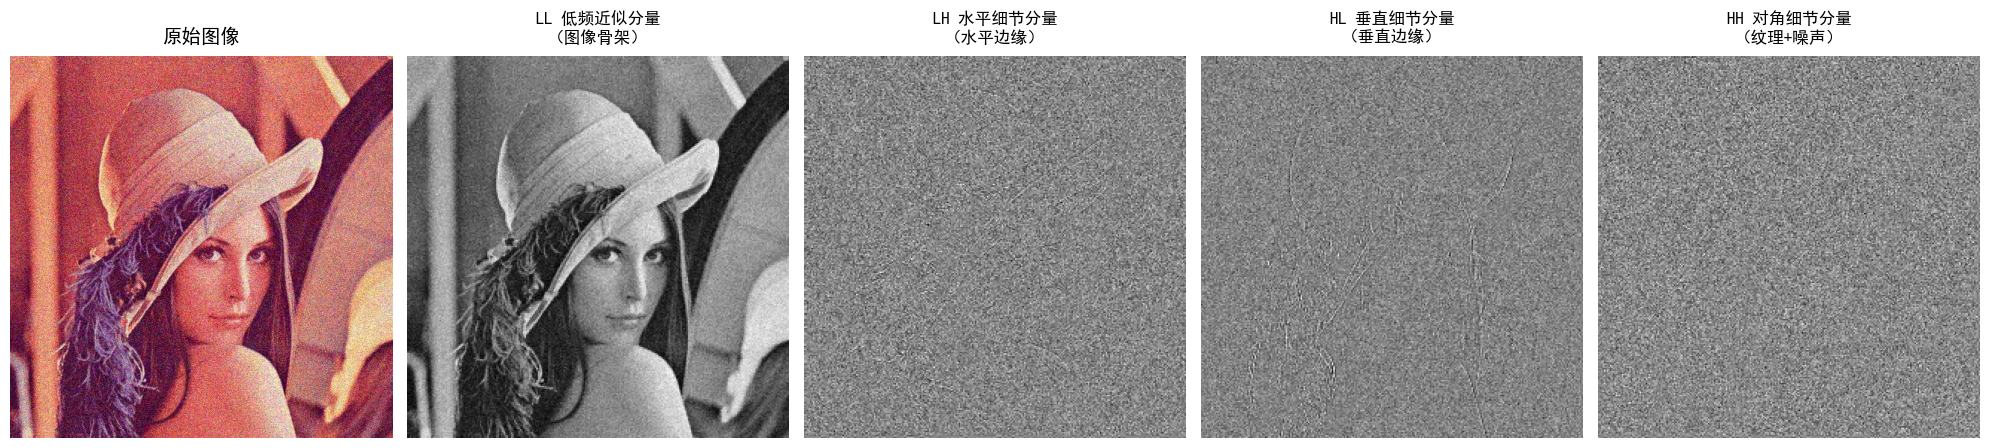

原始图像尺寸：(512, 512) (高×宽)
各频带尺寸：(257, 257) (均为原图1/4)
使用小波基：db2

所有图像可视化完成！


In [9]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def wavelet_bands_compare(image_path, wavelet='db2'):
    # 读取图像
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("无法读取图像！请检查路径或文件格式（jpg/png）")

    # 转灰度图（小波分解用）和RGB图（显示用）
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1级二维小波分解
    coeffs = pywt.wavedec2(gray_img, wavelet=wavelet, level=1)
    LL, (LH, HL, HH) = coeffs

    # 频带归一化（0-255）
    def normalize_band(band):
        min_val = np.min(band)
        max_val = np.max(band)
        if max_val - min_val == 0:
            return band
        return (band - min_val) / (max_val - min_val) * 255

    # 归一化处理
    LL_norm = normalize_band(LL).astype(np.uint8)
    LH_norm = normalize_band(LH).astype(np.uint8)
    HL_norm = normalize_band(HL).astype(np.uint8)
    HH_norm = normalize_band(HH).astype(np.uint8)

    # 绘制对比图（1行5列）
    plt.figure(figsize=(20, 6))

    # 原始图像
    plt.subplot(1, 5, 1)
    plt.imshow(img_rgb)
    plt.title('原始图像', fontsize=14, pad=10)
    plt.axis('off')

    # LL低频分量
    plt.subplot(1, 5, 2)
    plt.imshow(LL_norm, cmap='gray')
    plt.title('LL 低频近似分量\n（图像骨架）', fontsize=12, pad=10)
    plt.axis('off')

    # LH水平细节分量
    plt.subplot(1, 5, 3)
    plt.imshow(LH_norm, cmap='gray')
    plt.title('LH 水平细节分量\n（水平边缘）', fontsize=12, pad=10)
    plt.axis('off')

    # HL垂直细节分量
    plt.subplot(1, 5, 4)
    plt.imshow(HL_norm, cmap='gray')
    plt.title('HL 垂直细节分量\n（垂直边缘）', fontsize=12, pad=10)
    plt.axis('off')

    # HH对角细节分量
    plt.subplot(1, 5, 5)
    plt.imshow(HH_norm, cmap='gray')
    plt.title('HH 对角细节分量\n（纹理+噪声）', fontsize=12, pad=10)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 输出基础信息
    print("="*50)
    print(f"原始图像尺寸：{gray_img.shape} (高×宽)")
    print(f"各频带尺寸：{LL_norm.shape} (均为原图1/4)")
    print(f"使用小波基：{wavelet}")
    print("="*50)

# 批量处理测试图
if __name__ == "__main__":
    # 测试图像路径（替换为本地路径）
    test_images = [
        "building.jpg",
        "lighthouse.jpg",
        "cat.jpg",
        "lenna_noisy.jpg"
    ]

    # 批量执行
    for img_path in test_images:
        print(f"\n{img_path}")
        try:
            wavelet_bands_compare(image_path=img_path, wavelet='db2')
        except Exception as e:
            print(f"❌ 处理{img_path}失败：{str(e)}")

    print("\n所有图像可视化完成！")

原始图像尺寸：577×382
1级分解 - LL1尺寸：(290, 192)（原图1/4）
2级分解 - LL2尺寸：(146, 97)（原图1/16）
3级分解 - LL3尺寸：(74, 50)（原图1/64）


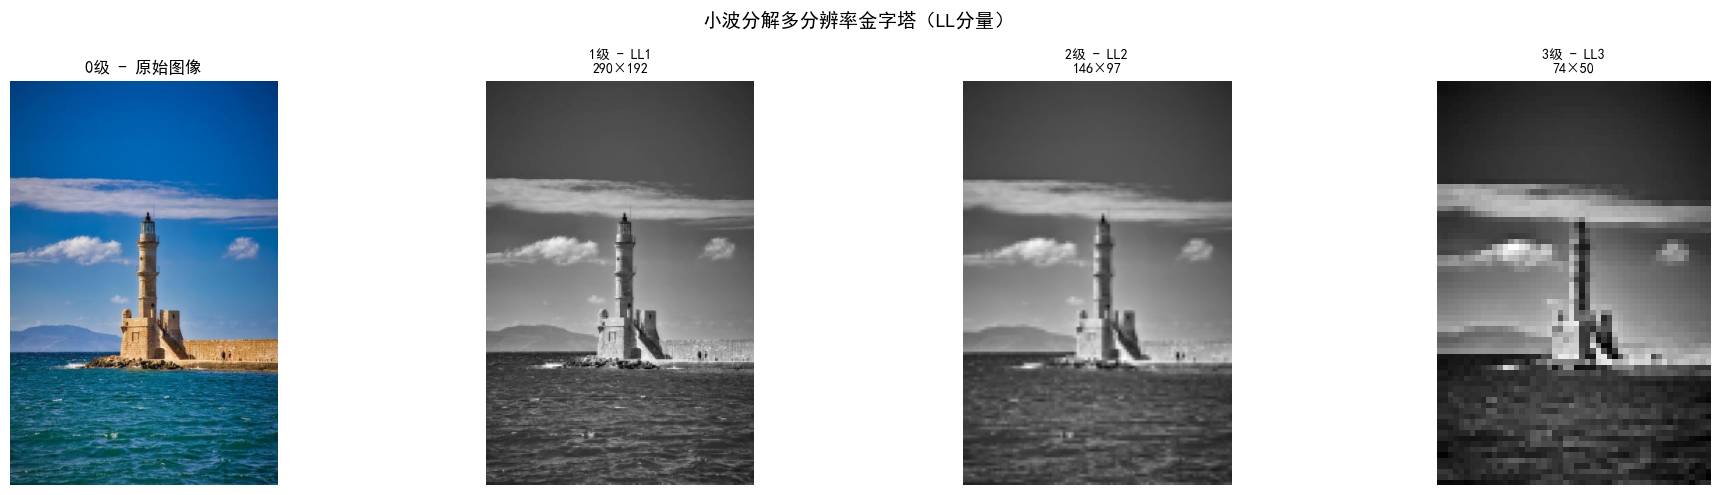

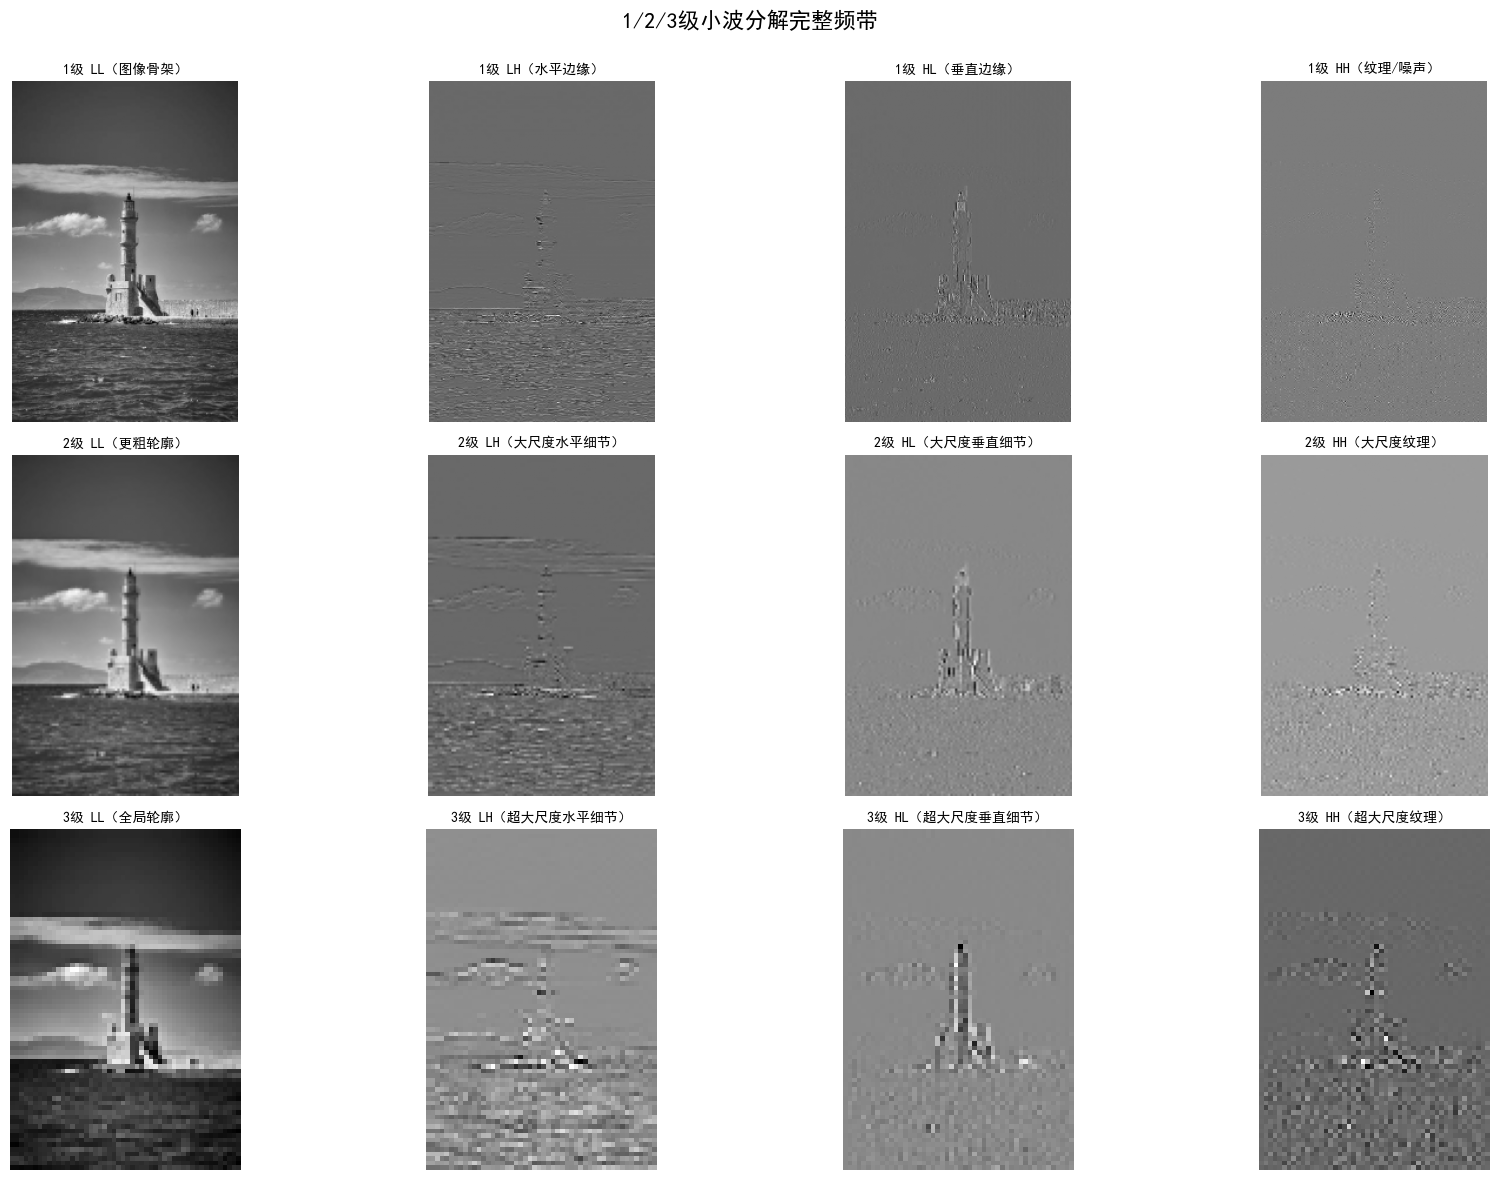


各层级应用价值：
1级分解：细节最丰富，噪声也最明显 → 适合去噪、精细边缘检测、细节增强
2级分解：平衡轮廓与细节 → 适合图像融合、特征提取、中等尺度分析
3级分解：仅保留全局轮廓，细节极少 → 适合图像压缩、轮廓提取、粗粒度分析


In [11]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

# 中文显示设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def show_all_level_wavelet(image_path, wavelet='db2'):
    # 读取图像
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("未找到lighthouse.jpg，请确认文件路径正确！")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = gray.shape
    print(f"原始图像尺寸：{h}×{w}")

    # 归一化函数
    def norm(band):
        return ((band - band.min()) / (band.max() - band.min() + 1e-8) * 255).astype(np.uint8)

    # 存储分解结果
    levels_data = {}

    # 1级分解
    coeffs1 = pywt.wavedec2(gray, wavelet=wavelet, level=1)
    LL1, (LH1, HL1, HH1) = coeffs1
    levels_data[1] = {
        'LL': norm(LL1), 'LH': norm(LH1), 'HL': norm(HL1), 'HH': norm(HH1),
        'shape': LL1.shape
    }
    print(f"1级分解 - LL1尺寸：{LL1.shape}（原图1/4）")

    # 2级分解
    coeffs2 = pywt.wavedec2(LL1, wavelet=wavelet, level=1)
    LL2, (LH2, HL2, HH2) = coeffs2
    levels_data[2] = {
        'LL': norm(LL2), 'LH': norm(LH2), 'HL': norm(HL2), 'HH': norm(HH2),
        'shape': LL2.shape
    }
    print(f"2级分解 - LL2尺寸：{LL2.shape}（原图1/16）")

    # 3级分解
    coeffs3 = pywt.wavedec2(LL2, wavelet=wavelet, level=1)
    LL3, (LH3, HL3, HH3) = coeffs3
    levels_data[3] = {
        'LL': norm(LL3), 'LH': norm(LH3), 'HL': norm(HL3), 'HH': norm(HH3),
        'shape': LL3.shape
    }
    print(f"3级分解 - LL3尺寸：{LL3.shape}（原图1/64）")

    # 可视化多分辨率金字塔
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title('0级 - 原始图像', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(levels_data[1]['LL'], cmap='gray')
    plt.title(f'1级 - LL1\n{levels_data[1]["shape"][0]}×{levels_data[1]["shape"][1]}', fontsize=10)
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(levels_data[2]['LL'], cmap='gray')
    plt.title(f'2级 - LL2\n{levels_data[2]["shape"][0]}×{levels_data[2]["shape"][1]}', fontsize=10)
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(levels_data[3]['LL'], cmap='gray')
    plt.title(f'3级 - LL3\n{levels_data[3]["shape"][0]}×{levels_data[3]["shape"][1]}', fontsize=10)
    plt.axis('off')

    plt.suptitle('小波分解多分辨率金字塔（LL分量）', fontsize=14)
    plt.tight_layout()
    plt.show()

    # 可视化各层级完整频带
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    fig.suptitle('1/2/3级小波分解完整频带', fontsize=16)

    # 1级分解行
    axes[0, 0].imshow(levels_data[1]['LL'], cmap='gray')
    axes[0, 0].set_title('1级 LL（图像骨架）', fontsize=10)
    axes[0, 0].axis('off')
    axes[0, 1].imshow(levels_data[1]['LH'], cmap='gray')
    axes[0, 1].set_title('1级 LH（水平边缘）', fontsize=10)
    axes[0, 1].axis('off')
    axes[0, 2].imshow(levels_data[1]['HL'], cmap='gray')
    axes[0, 2].set_title('1级 HL（垂直边缘）', fontsize=10)
    axes[0, 2].axis('off')
    axes[0, 3].imshow(levels_data[1]['HH'], cmap='gray')
    axes[0, 3].set_title('1级 HH（纹理/噪声）', fontsize=10)
    axes[0, 3].axis('off')

    # 2级分解行
    axes[1, 0].imshow(levels_data[2]['LL'], cmap='gray')
    axes[1, 0].set_title('2级 LL（更粗轮廓）', fontsize=10)
    axes[1, 0].axis('off')
    axes[1, 1].imshow(levels_data[2]['LH'], cmap='gray')
    axes[1, 1].set_title('2级 LH（大尺度水平细节）', fontsize=10)
    axes[1, 1].axis('off')
    axes[1, 2].imshow(levels_data[2]['HL'], cmap='gray')
    axes[1, 2].set_title('2级 HL（大尺度垂直细节）', fontsize=10)
    axes[1, 2].axis('off')
    axes[1, 3].imshow(levels_data[2]['HH'], cmap='gray')
    axes[1, 3].set_title('2级 HH（大尺度纹理）', fontsize=10)
    axes[1, 3].axis('off')

    # 3级分解行
    axes[2, 0].imshow(levels_data[3]['LL'], cmap='gray')
    axes[2, 0].set_title('3级 LL（全局轮廓）', fontsize=10)
    axes[2, 0].axis('off')
    axes[2, 1].imshow(levels_data[3]['LH'], cmap='gray')
    axes[2, 1].set_title('3级 LH（超大尺度水平细节）', fontsize=10)
    axes[2, 1].axis('off')
    axes[2, 2].imshow(levels_data[3]['HL'], cmap='gray')
    axes[2, 2].set_title('3级 HL（超大尺度垂直细节）', fontsize=10)
    axes[2, 2].axis('off')
    axes[2, 3].imshow(levels_data[3]['HH'], cmap='gray')
    axes[2, 3].set_title('3级 HH（超大尺度纹理）', fontsize=10)
    axes[2, 3].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

    # 输出应用说明
    print("\n各层级应用价值：")
    print("1级分解：细节最丰富，噪声也最明显 → 适合去噪、精细边缘检测、细节增强")
    print("2级分解：平衡轮廓与细节 → 适合图像融合、特征提取、中等尺度分析")
    print("3级分解：仅保留全局轮廓，细节极少 → 适合图像压缩、轮廓提取、粗粒度分析")

# 执行主函数
if __name__ == "__main__":
    try:
        show_all_level_wavelet(image_path="lighthouse.jpg", wavelet='db2')
    except Exception as e:
        print(f"程序执行错误：{str(e)}")